<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install pandas numpy matplotlib seaborn scikit-learn requests -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests, io, re, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


dataset download

Saving HDFS_2k.log_structured.csv to HDFS_2k.log_structured (3).csv
Loaded file: HDFS_2k.log_structured (3).csv
Shape : (2000, 9)
Columns: ['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']

--- First 5 rows ---
   LineId   Date    Time  Pid Level                     Component  \
0       1  81109  203615  148  INFO  dfs.DataNode$PacketResponder   
1       2  81109  203807  222  INFO  dfs.DataNode$PacketResponder   
2       3  81109  204005   35  INFO              dfs.FSNamesystem   
3       4  81109  204015  308  INFO  dfs.DataNode$PacketResponder   
4       5  81109  204106  329  INFO  dfs.DataNode$PacketResponder   

                                             Content EventId  \
0  PacketResponder 1 for block blk_38865049064139...     E10   
1  PacketResponder 0 for block blk_-6952295868487...     E10   
2  BLOCK* NameSystem.addStoredBlock: blockMap upd...      E6   
3  PacketResponder 2 for block blk_82291938032499...     E10   
4  Packet

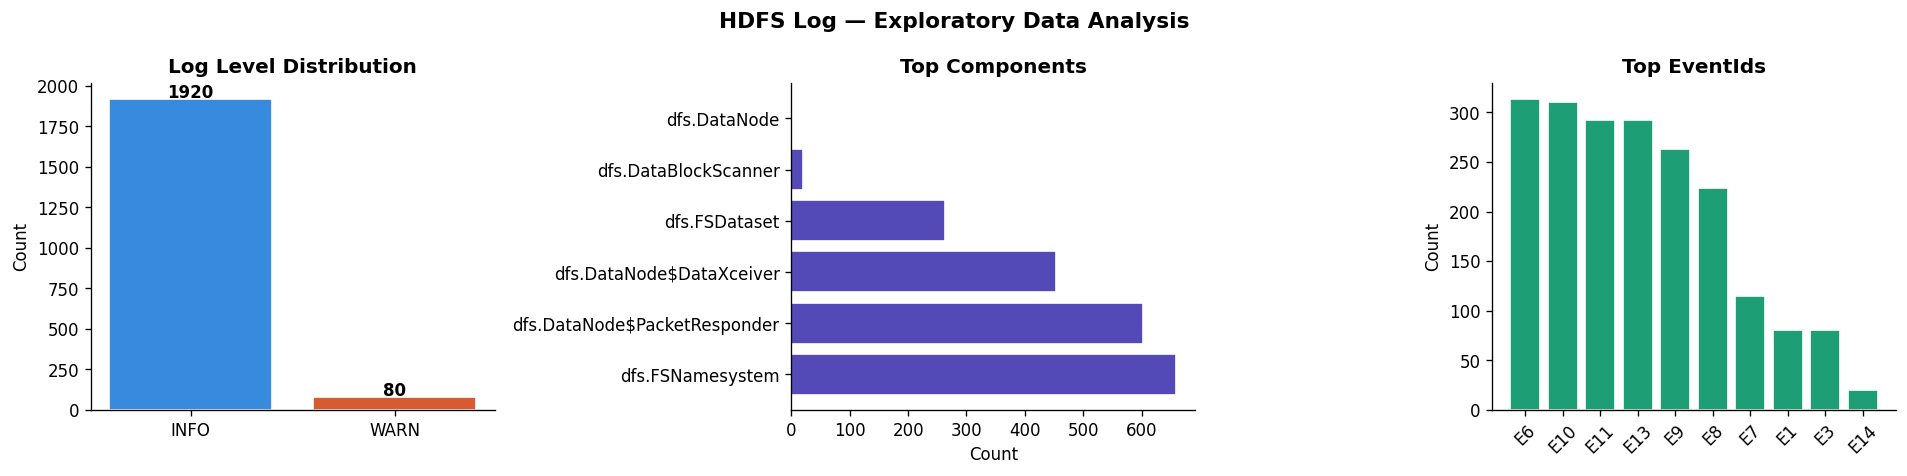


WARN rows : 80 (4.0%)


In [12]:
# ── Cell 2: Load & Explore ────────────────────────────────────────
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

# Upload file
uploaded = files.upload()

# Automatically detect correct filename
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

# Basic info
print(f"Loaded file: {filename}")
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\n--- First 5 rows ---")
print(df.head())

# ── Data Cleaning (Important) ─────────────────────────────────────
# Handle missing values safely
df['Level'] = df.get('Level', pd.Series()).fillna('UNKNOWN')
df['Component'] = df.get('Component', pd.Series()).fillna('UNKNOWN')
df['EventId'] = df.get('EventId', pd.Series()).fillna('UNKNOWN')

# ── EDA Visualisations ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Log Level distribution
level_counts = df['Level'].value_counts()
axes[0].bar(level_counts.index, level_counts.values,
            color=['#378ADD', '#D85A30', '#999999'], edgecolor='white')
axes[0].set_title('Log Level Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

for i, v in enumerate(level_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Component distribution
comp_counts = df['Component'].value_counts().head(10)  # limit for readability
axes[1].barh(comp_counts.index, comp_counts.values,
             color='#534AB7', edgecolor='white')
axes[1].set_title('Top Components', fontweight='bold')
axes[1].set_xlabel('Count')

# 3. EventId distribution
event_counts = df['EventId'].value_counts().head(10)
axes[2].bar(event_counts.index, event_counts.values,
            color='#1D9E75', edgecolor='white')
axes[2].set_title('Top EventIds', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

# Layout
plt.suptitle('HDFS Log — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight')
plt.show()

# ── Summary Stats ────────────────────────────────────────────────
warn_count = (df['Level'] == 'WARN').sum()
warn_percent = (df['Level'] == 'WARN').mean() * 100

print(f"\nWARN rows : {warn_count} ({warn_percent:.1f}%)")

feature selection

Features used: ['level_flag', 'component_enc', 'event_enc', 'pid_norm', 'time_sec', 'warn_rolling']
       level_flag  component_enc  event_enc   pid_norm   time_sec  warn_rolling
count    2000.000       2000.000   2000.000   2000.000   2000.000      2000.000
mean        0.040          3.532      6.648   7771.288  39382.170         0.040
std         0.196          1.219      4.726   9053.587  25076.512         0.127
min         0.000          0.000      0.000     13.000     37.000         0.000
25%         0.000          3.000      2.000     28.000  19386.750         0.000
50%         0.000          3.000      7.000   2883.500  33938.000         0.000
75%         0.000          5.000     11.000  15851.250  54686.750         0.000
max         1.000          5.000     13.000  26895.000  86391.000         0.850


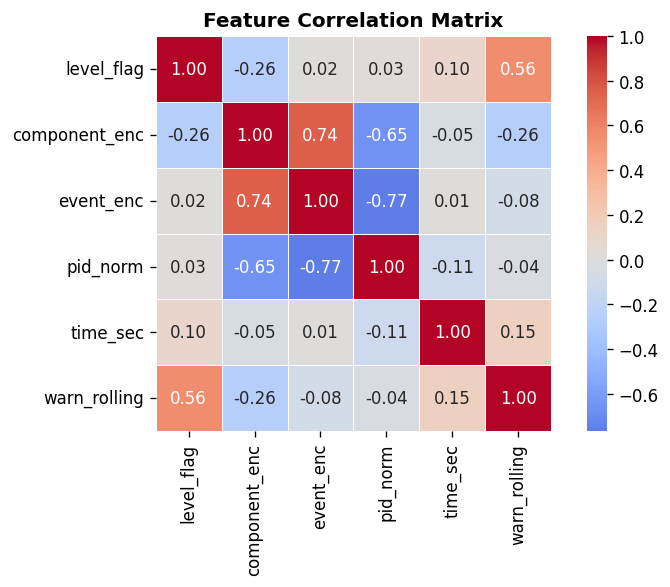

In [15]:
# ── Cell 3: Feature Engineering ──────────────────────────────────
# Required imports (you missed these)
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# The CSV has: LineId, Date, Time, Pid, Level, Component, Content,
#              EventId, EventTemplate

# Initialize encoders
le_comp  = LabelEncoder()
le_event = LabelEncoder()

# Ensure columns exist (safe handling)
df['Level'] = df.get('Level', 'INFO')
df['Component'] = df.get('Component', 'UNKNOWN')
df['EventId'] = df.get('EventId', 'UNKNOWN')

# Feature creation
df['level_flag']    = (df['Level'] == 'WARN').astype(int)
df['component_enc'] = le_comp.fit_transform(df['Component'].astype(str))
df['event_enc']     = le_event.fit_transform(df['EventId'].astype(str))

# Handle PID safely
df['Pid'] = pd.to_numeric(df.get('Pid', 0), errors='coerce').fillna(0)
df['pid_norm'] = df['Pid']

# Time conversion (HHMMSS → seconds)
def time_to_sec(t):
    try:
        t = str(int(t)).zfill(6)
        return int(t[:2])*3600 + int(t[2:4])*60 + int(t[4:])
    except:
        return 0

df['time_sec'] = df['Time'].apply(time_to_sec)

# Rolling WARN rate (window = 20)
df['warn_rolling'] = (df['Level'] == 'WARN').rolling(20, min_periods=1).mean()

# Feature list
FEATURE_COLS = ['level_flag', 'component_enc', 'event_enc',
                'pid_norm', 'time_sec', 'warn_rolling']

X_raw = df[FEATURE_COLS].copy()

print("Features used:", FEATURE_COLS)
print(X_raw.describe().round(3).to_string())

# ── Correlation Heatmap ─────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(X_raw.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True)

plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()

Scale and PCA

PCA PC1 explains 41.7%  |  PC2 explains 27.1%
Total variance captured: 68.9%


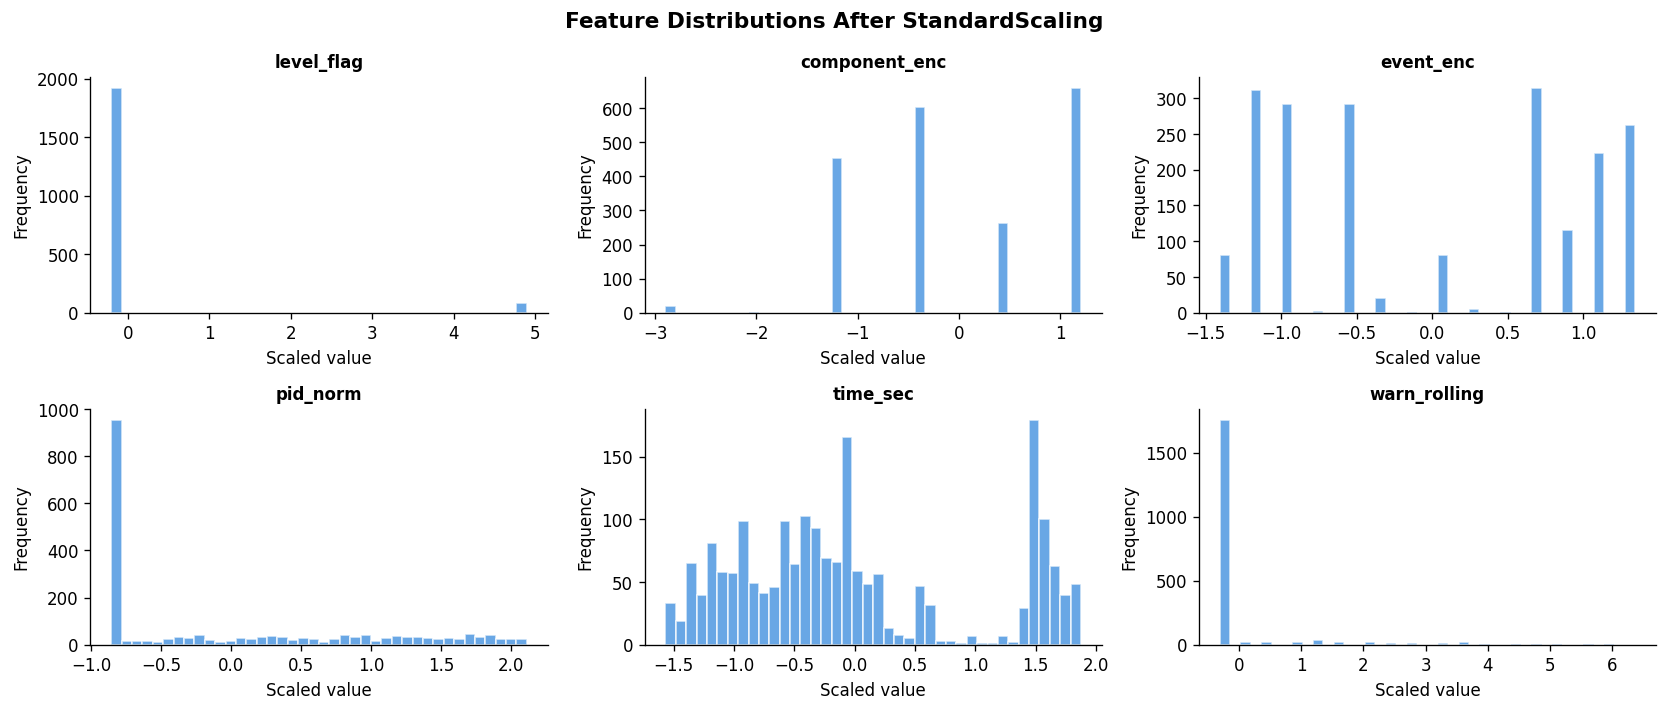

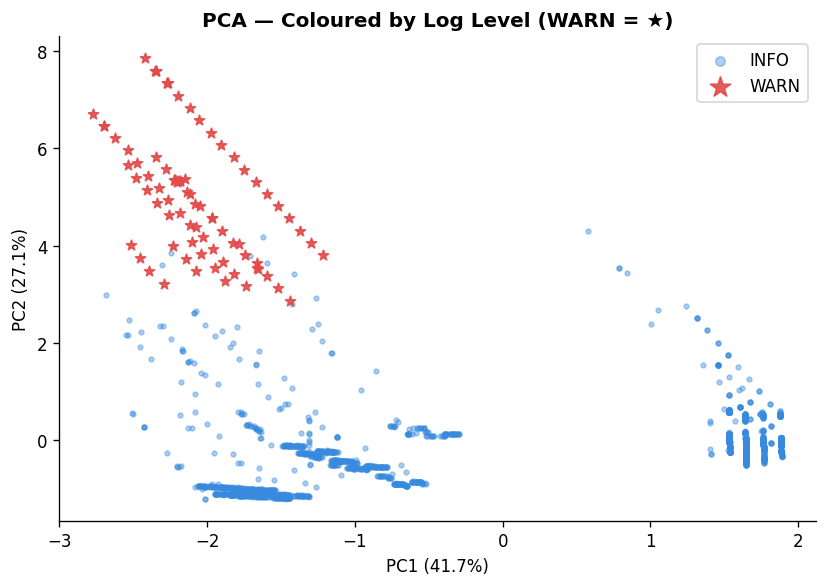

In [16]:
# ── Cell 4: Scaling & PCA ────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
exp_var  = pca.explained_variance_ratio_ * 100

print(f"PCA PC1 explains {exp_var[0]:.1f}%  |  PC2 explains {exp_var[1]:.1f}%")
print(f"Total variance captured: {exp_var.sum():.1f}%")

# Raw feature distribution after scaling
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, (col, ax) in enumerate(zip(FEATURE_COLS, axes.flatten())):
    ax.hist(X_scaled[:, i], bins=40, color='#378ADD', alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Scaled value')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions After StandardScaling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scaled_distributions.png', bbox_inches='tight')
plt.show()

# PCA scatter — colour by Level (INFO / WARN)
plt.figure(figsize=(7, 5))
for lvl, col in [('INFO', '#378ADD'), ('WARN', '#E24B4A')]:
    mask = df['Level'] == lvl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=(40 if lvl=='WARN' else 8),
                alpha=(0.9 if lvl=='WARN' else 0.4),
                c=col, label=lvl,
                marker=('*' if lvl=='WARN' else 'o'), zorder=(5 if lvl=='WARN' else 2))
plt.title('PCA — Coloured by Log Level (WARN = ★)', fontweight='bold')
plt.xlabel(f'PC1 ({exp_var[0]:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]:.1f}%)')
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig('pca_level.png', bbox_inches='tight')
plt.show()

K means

  k       Inertia    Silhouette
--------------------------------
  2        7233.7        0.4658
  3        4591.9        0.5210
  4        3609.5        0.4879
  5        2887.1        0.5032
  6        2226.8        0.4930
  7        1862.0        0.5116
  8        1689.3        0.5064
  9        1555.2        0.5220

🏆 Optimal k = 9  (Silhouette = 0.5220)


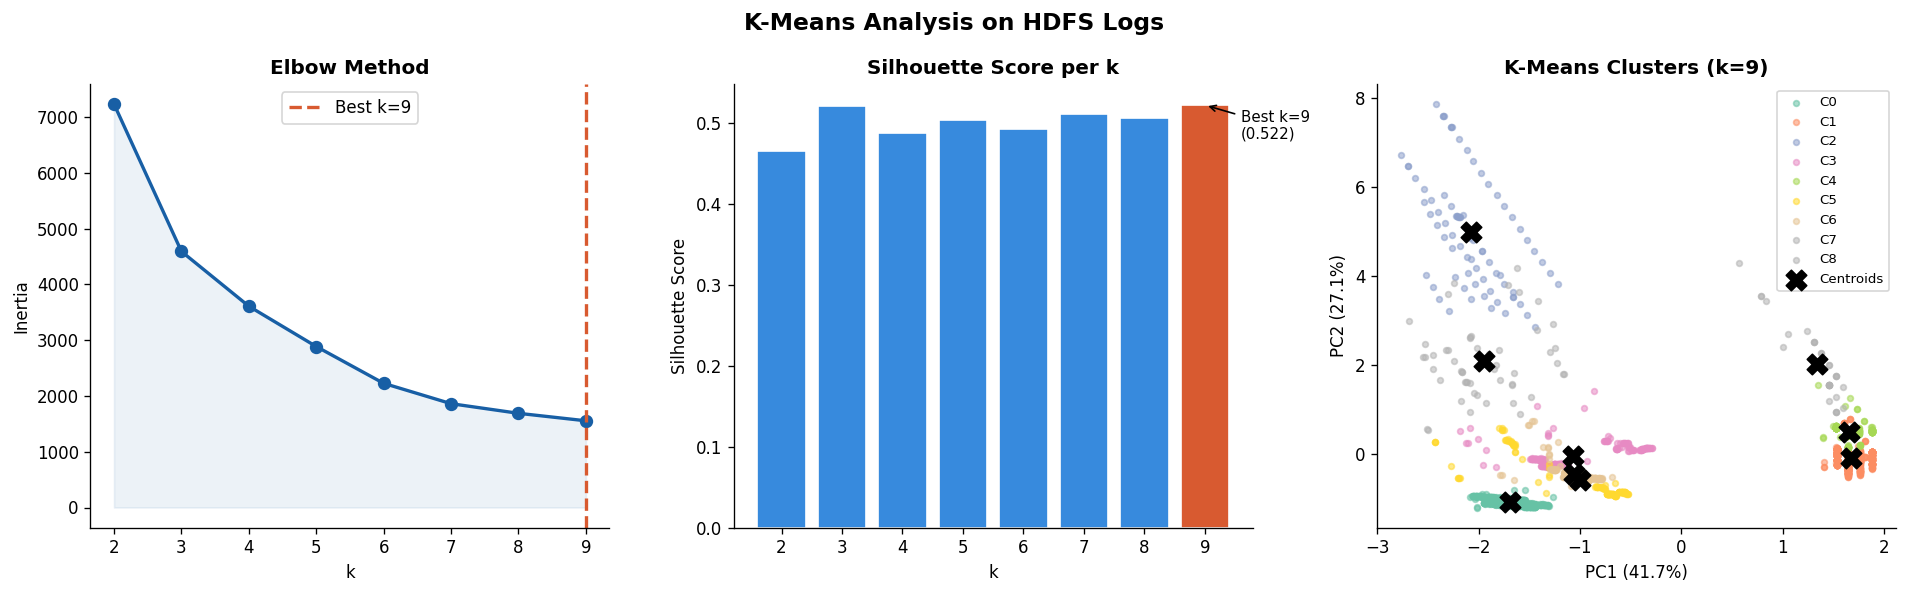


📊 Cluster breakdown:
                Total  WARNs  WARN rate
kmeans_cluster                         
0                 426      0        0.0
1                 672      0        0.0
2                  80     80        1.0
3                 216      0        0.0
4                 219      0        0.0
5                 129      0        0.0
6                 174      0        0.0
7                  53      0        0.0
8                  31      0        0.0


In [17]:
# ── Cell 5: K-Means + Silhouette ─────────────────────────────────
k_range    = range(2, 10)
inertias   = []
sil_scores = []

print(f"{'k':>3}  {'Inertia':>12}  {'Silhouette':>12}")
print("-"*32)
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil    = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"{k:>3}  {km.inertia_:>12.1f}  {sil:>12.4f}")

best_k = k_range.start + np.argmax(sil_scores)
print(f"\n🏆 Optimal k = {best_k}  (Silhouette = {max(sil_scores):.4f})")

# Train final model
km_best   = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_best.fit_predict(X_scaled)

# ── Three-panel plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Elbow
axes[0].plot(k_range, inertias, 'o-', color='#185FA5', lw=2, ms=7)
axes[0].axvline(best_k, color='#D85A30', ls='--', lw=2, label=f'Best k={best_k}')
axes[0].fill_between(k_range, inertias, alpha=0.08, color='#185FA5')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].legend()

# Silhouette bars
bar_cols = ['#D85A30' if k == best_k else '#378ADD' for k in k_range]
axes[1].bar(k_range, sil_scores, color=bar_cols, edgecolor='white')
axes[1].set_title('Silhouette Score per k', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].annotate(f'Best k={best_k}\n({max(sil_scores):.3f})',
    xy=(best_k, max(sil_scores)),
    xytext=(best_k+0.6, max(sil_scores)*0.92),
    arrowprops=dict(arrowstyle='->'), fontsize=9)

# PCA coloured by cluster
palette = plt.cm.Set2(np.linspace(0, 1, best_k))
for cl in range(best_k):
    mask = km_labels == cl
    axes[2].scatter(X_pca[mask,0], X_pca[mask,1],
                   s=12, alpha=0.55, color=palette[cl], label=f'C{cl}')
centroids_pca = pca.transform(km_best.cluster_centers_)
axes[2].scatter(centroids_pca[:,0], centroids_pca[:,1],
               c='black', s=150, marker='X', zorder=6, label='Centroids')
axes[2].set_title(f'K-Means Clusters (k={best_k})', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({exp_var[0]:.1f}%)')
axes[2].set_ylabel(f'PC2 ({exp_var[1]:.1f}%)')
axes[2].legend(fontsize=8)

plt.suptitle('K-Means Analysis on HDFS Logs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans.png', bbox_inches='tight')
plt.show()

# Cluster breakdown with WARN rate per cluster
df['kmeans_cluster'] = km_labels
print("\n📊 Cluster breakdown:")
print(df.groupby('kmeans_cluster')['level_flag']
        .agg(['count', 'sum', 'mean'])
        .rename(columns={'count':'Total','sum':'WARNs','mean':'WARN rate'})
        .round(3).to_string())

DBSCAN

eps            = 0.4304
min_samples    = 8
Clusters found = 19
Noise points   = 183  (9.15%) ← potential intrusions

WARN rate — noise  : 36.1%
WARN rate — normal : 0.8%


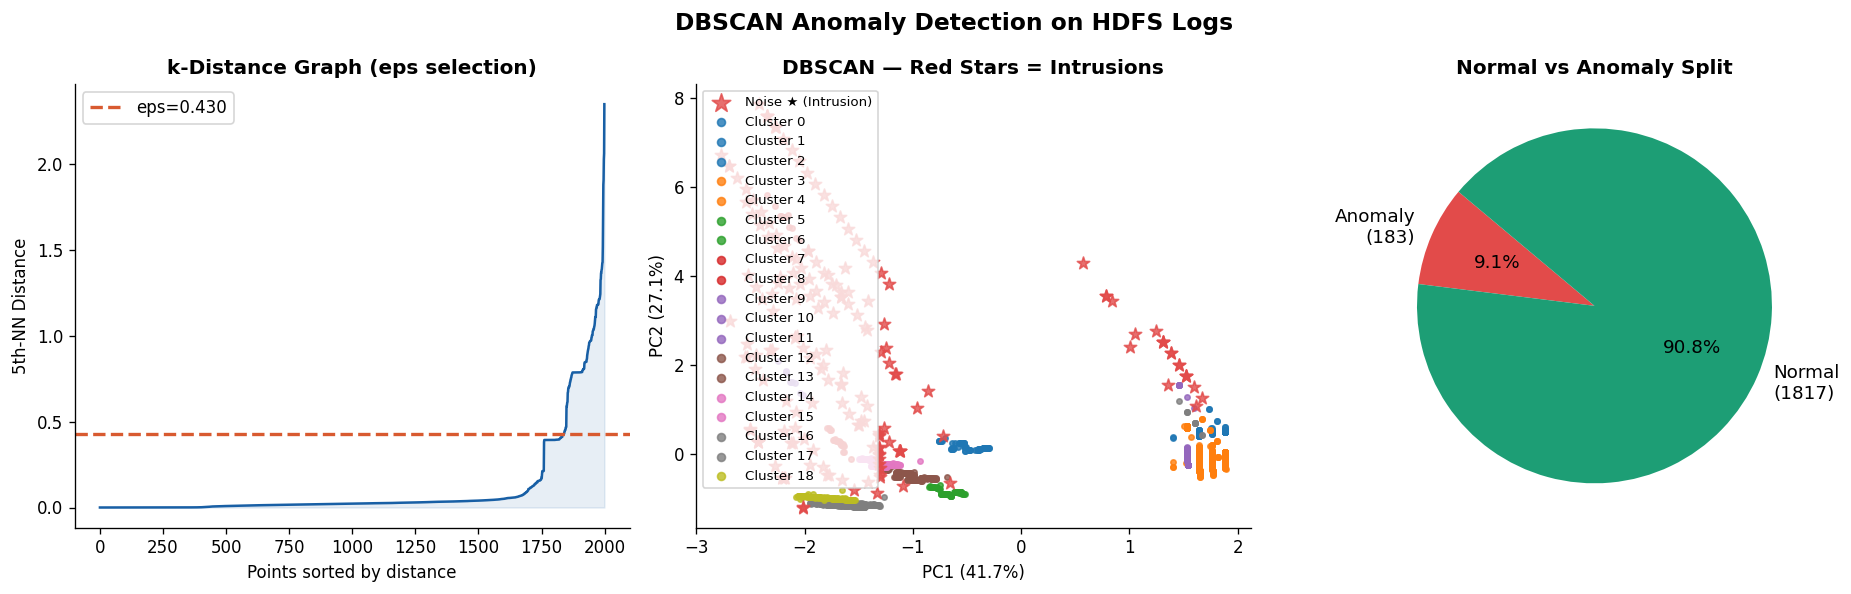

In [22]:
# ── Cell 6: DBSCAN ───────────────────────────────────────────────

# Step A: k-distance graph to pick eps automatically
nbrs       = NearestNeighbors(n_neighbors=5).fit(X_scaled)
dists, _   = nbrs.kneighbors(X_scaled)
k_dist     = np.sort(dists[:, -1])
eps_val    = float(np.percentile(k_dist, 92))   # 92nd pct → reasonable eps

# Step B: Run DBSCAN
dbscan    = DBSCAN(eps=eps_val, min_samples=8)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
noise_pct  = n_noise / len(db_labels) * 100

print(f"eps            = {eps_val:.4f}")
print(f"min_samples    = 8")
print(f"Clusters found = {n_clusters}")
print(f"Noise points   = {n_noise}  ({noise_pct:.2f}%) ← potential intrusions")

# WARN rate among noise vs normal points
df['dbscan_label'] = db_labels
warn_in_noise  = df[db_labels==-1]['level_flag'].mean()
warn_in_normal = df[db_labels!=-1]['level_flag'].mean()
print(f"\nWARN rate — noise  : {warn_in_noise*100:.1f}%")
print(f"WARN rate — normal : {warn_in_normal*100:.1f}%")

# ── Three-panel plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# k-dist graph
axes[0].plot(k_dist, color='#185FA5', lw=1.5)
axes[0].axhline(eps_val, color='#D85A30', ls='--', lw=2, label=f'eps={eps_val:.3f}')
axes[0].fill_between(range(len(k_dist)), k_dist, alpha=0.1, color='#185FA5')
axes[0].set_title('k-Distance Graph (eps selection)', fontweight='bold')
axes[0].set_xlabel('Points sorted by distance')
axes[0].set_ylabel('5th-NN Distance')
axes[0].legend()

# DBSCAN PCA scatter
unique_labels = sorted(set(db_labels))
cmap_cl = plt.cm.tab10(np.linspace(0,0.8, n_clusters))
col_map = {-1: '#E24B4A'}
for i, l in enumerate([x for x in unique_labels if x != -1]):
    col_map[l] = cmap_cl[i]

for lbl in unique_labels:
    mask = db_labels == lbl
    nm   = 'Noise ★ (Intrusion)' if lbl==-1 else f'Cluster {lbl}'
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1],
                   s=(60 if lbl==-1 else 10), alpha=0.8, c=col_map[lbl],
                   label=nm, zorder=(5 if lbl==-1 else 2),
                   marker=('*' if lbl==-1 else 'o'))
axes[1].set_title('DBSCAN — Red Stars = Intrusions', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({exp_var[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({exp_var[1]:.1f}%)')
axes[1].legend(fontsize=8, markerscale=1.5)

# Pie: normal vs anomaly
wedges, texts, autos = axes[2].pie(
    [n_noise, len(db_labels)-n_noise],
    labels=[f'Anomaly\n({n_noise})', f'Normal\n({len(db_labels)-n_noise})'],
    colors=['#E24B4A', '#1D9E75'], autopct='%1.1f%%',
    startangle=140, textprops=dict(fontsize=11))
axes[2].set_title('Normal vs Anomaly Split', fontweight='bold')

plt.suptitle('DBSCAN Anomaly Detection on HDFS Logs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan.png', bbox_inches='tight')
plt.show()

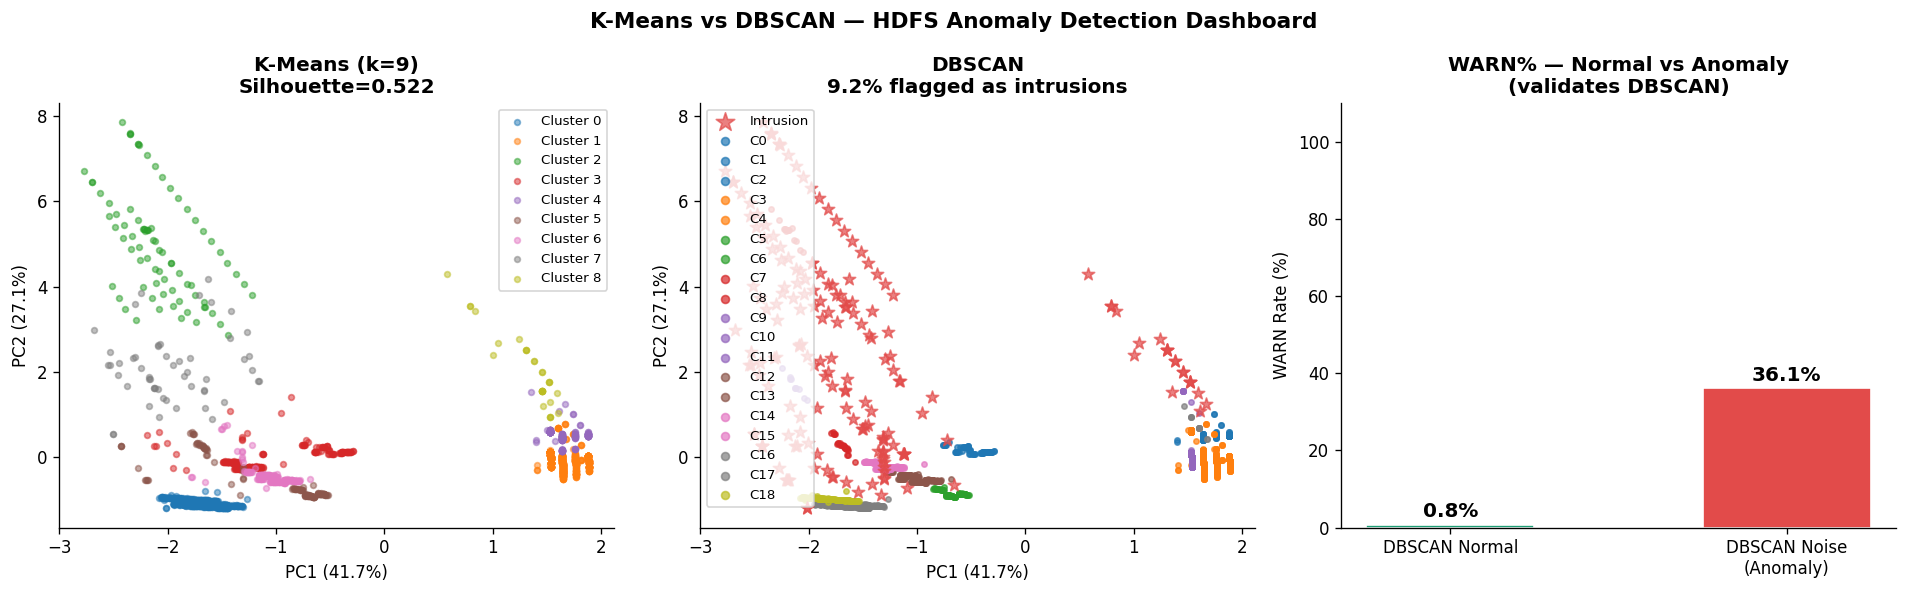


══════════════════════════════════════════════════════════
         FINAL RESULTS — Q2 ANOMALY DETECTION
══════════════════════════════════════════════════════════
  Dataset         : HDFS_2k_log_structured.csv
  Total records   : 2000
  Features used   : ['level_flag', 'component_enc', 'event_enc', 'pid_norm', 'time_sec', 'warn_rolling']
──────────────────────────────────────────────────────────
  [K-Means]
    Optimal k            : 9
    Best Silhouette Score : 0.5220
    Inertia (best k)     : 1555.15
──────────────────────────────────────────────────────────
  [DBSCAN]
    eps                  : 0.4304
    min_samples          : 8
    Clusters formed      : 19
    Anomalies (noise)    : 183 (9.15%)
    WARN% in anomalies   : 36.1%
    WARN% in normal      : 0.8%
══════════════════════════════════════════════════════════


In [23]:
# ── Cell 7: Final Comparison Dashboard ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# K-Means PCA
for cl in range(best_k):
    mask = km_labels == cl
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                   s=12, alpha=0.5, label=f'Cluster {cl}')
axes[0].set_title(f'K-Means (k={best_k})\nSilhouette={max(sil_scores):.3f}',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 ({exp_var[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({exp_var[1]:.1f}%)')
axes[0].legend(fontsize=8)

# DBSCAN PCA
for lbl in unique_labels:
    mask = db_labels == lbl
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1],
                   s=(60 if lbl==-1 else 10), alpha=0.7, c=col_map[lbl],
                   label=('Intrusion' if lbl==-1 else f'C{lbl}'),
                   marker=('*' if lbl==-1 else 'o'),
                   zorder=(5 if lbl==-1 else 2))
axes[1].set_title(f'DBSCAN\n{noise_pct:.1f}% flagged as intrusions', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({exp_var[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({exp_var[1]:.1f}%)')
axes[1].legend(fontsize=8, markerscale=1.5)

# WARN rate comparison bar
categories  = ['DBSCAN Normal', 'DBSCAN Noise\n(Anomaly)']
warn_rates  = [warn_in_normal*100, warn_in_noise*100]
bar_c       = ['#1D9E75', '#E24B4A']
bars        = axes[2].bar(categories, warn_rates, color=bar_c, edgecolor='white', width=0.5)
axes[2].set_title('WARN% — Normal vs Anomaly\n(validates DBSCAN)', fontweight='bold')
axes[2].set_ylabel('WARN Rate (%)')
axes[2].set_ylim([0, 110])
for bar, val in zip(bars, warn_rates):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('K-Means vs DBSCAN — HDFS Anomaly Detection Dashboard',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_dashboard.png', bbox_inches='tight')
plt.show()

# ── Final Printed Results ────────────────────────────────────────
print("\n" + "═"*58)
print("         FINAL RESULTS — Q2 ANOMALY DETECTION")
print("═"*58)
print(f"  Dataset         : HDFS_2k_log_structured.csv")
print(f"  Total records   : {len(df)}")
print(f"  Features used   : {FEATURE_COLS}")
print("─"*58)
print(f"  [K-Means]")
print(f"    Optimal k            : {best_k}")
print(f"    Best Silhouette Score : {max(sil_scores):.4f}")
print(f"    Inertia (best k)     : {inertias[best_k-2]:.2f}")
print("─"*58)
print(f"  [DBSCAN]")
print(f"    eps                  : {eps_val:.4f}")
print(f"    min_samples          : 8")
print(f"    Clusters formed      : {n_clusters}")
print(f"    Anomalies (noise)    : {n_noise} ({noise_pct:.2f}%)")
print(f"    WARN% in anomalies   : {warn_in_noise*100:.1f}%")
print(f"    WARN% in normal      : {warn_in_normal*100:.1f}%")
print("═"*58)